# Master Dual Equation: `intervalinf` × `pygeoinf` convex analysis

**Scenario:** Infer a property of an unknown function $\bar{m} \in L^2[0,1]$ from two noisy
integral observations, using the Backus–Gilbert master dual equation.

$$
h_{\mathcal{U}}(q)
= \inf_{\lambda \in \mathcal{D}}
\bigl\{
  \langle \lambda, \tilde{d} \rangle_{\mathcal{D}}
  + \sigma_{\mathcal{B}}(T^* q - G^* \lambda)
  + \sigma_{\mathcal{V}}(-\lambda)
\bigr\}
$$

- $\mathcal{M} = L^2[0,1]$ — **model space** (intervalinf `Lebesgue`)
- $\mathcal{D} = \mathbb{R}^2$ — **data space** (pygeoinf `EuclideanSpace(2)`)
- $\mathcal{P} = \mathbb{R}^1$ — **property space** (pygeoinf `EuclideanSpace(1)`)
- $G: \mathcal{M} \to \mathcal{D}$ — SOLA operator (two boxcar averages)
- $T: \mathcal{M} \to \mathcal{P}$ — SOLA operator (local average near $x=0.3$)
- $\sigma_{\mathcal{B}}$ — support function of a ball in $L^2[0,1]$ (pygeoinf `BallSupportFunction`)
- $\sigma_{\mathcal{V}}$ — support function of a ball in $\mathbb{R}^2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── intervalinf: function spaces on [0,1] ──────────────────────────────────
from intervalinf import Lebesgue, IntervalDomain, Function
from intervalinf.operators import SOLAOperator
from intervalinf.core.config import IntegrationConfig

# ── pygeoinf: Hilbert spaces, support functions, optimisation ─────────────
from pygeoinf import EuclideanSpace, BallSupportFunction, SubgradientDescent
from pygeoinf.backus_gilbert import DualMasterCostFunction

print("All imports OK ✓")

All imports OK ✓


## 1. Spaces

| Space | Type | Dim | Role |
|---|---|---|---|
| $\mathcal{M} = L^2[0,1]$ | `intervalinf.Lebesgue` | ∞ | unknowns (functions) |
| $\mathcal{D} = \mathbb{R}^2$ | `pygeoinf.EuclideanSpace(2)` | 2 | noisy observations |
| $\mathcal{P} = \mathbb{R}^1$ | `pygeoinf.EuclideanSpace(1)` | 1 | property to bound |

In [2]:
# ── Model space: L²[0,1] ──────────────────────────────────────────────────
function_domain = IntervalDomain(0.0, 1.0)
M = Lebesgue(0, function_domain, basis=None)       # intervalinf Lebesgue space

# ── Data space: ℝ² (2 integral observations) ─────────────────────────────
D = EuclideanSpace(2)                               # pygeoinf EuclideanSpace

# ── Property space: ℝ¹ (scalar quantity of interest) ─────────────────────
P = EuclideanSpace(1)                               # pygeoinf EuclideanSpace

print(f"Model space  : {M}")
print(f"Data space   : {D}")
print(f"Property space: {P}")

Model space  : <intervalinf.spaces.lebesgue.Lebesgue object at 0x7f3d7ac690d0>
Data space   : <pygeoinf.hilbert_space.EuclideanSpace object at 0x7f3d7ac69650>
Property space: <pygeoinf.hilbert_space.EuclideanSpace object at 0x7f3d7ac69610>


## 2. Forward operators $G$ and $T$ via `SOLAOperator`

Both operators are built from **integral kernels** using intervalinf's `SOLAOperator`:

$$G(m) = \begin{pmatrix} 2\int_0^{0.5} m(x)\,dx \\ 2\int_{0.5}^1 m(x)\,dx \end{pmatrix}, \qquad
T(m) = 5 \int_{0.2}^{0.4} m(x)\,dx$$

The adjoint $G^*\lambda = \sum_i \lambda_i g_i(x)$ reconstructs a function in $L^2[0,1]$ from data
coefficients — `SOLAOperator` computes this automatically via its `dual_mapping`.

In [3]:
cfg = IntegrationConfig(method='simpson', n_points=400)

# ── Data kernels: two boxcar functions covering left/right halves ─────────
# g_1(x) = 2·1_{[0, 0.5]},  G_1(m) = 2∫₀^{0.5} m dx  (twice the left-half mean)
# g_2(x) = 2·1_{[0.5, 1]},  G_2(m) = 2∫_{0.5}^1 m dx

g1 = lambda x: np.where((x >= 0.0) & (x <= 0.5), 2.0, 0.0)
g2 = lambda x: np.where((x > 0.5) & (x <= 1.0), 2.0, 0.0)

G = SOLAOperator(M, D, kernels=[g1, g2], integration_config=cfg)

# ── Property kernel: local average on [0.2, 0.4] ─────────────────────────
# k_T(x) = 5·1_{[0.2,0.4]},  T(m) = 5∫_{0.2}^{0.4} m dx  (mean on [0.2,0.4])

k_T = lambda x: np.where((x >= 0.2) & (x <= 0.4), 5.0, 0.0)
T   = SOLAOperator(M, P, kernels=[k_T], integration_config=cfg)

print(f"G: {G}")
print(f"T: {T}")

G: SOLAOperator: <intervalinf.spaces.lebesgue.Lebesgue object at 0x7f3d7ac690d0> -> <pygeoinf.hilbert_space.EuclideanSpace object at 0x7f3d7ac69650>
  Uses 2 kernels from direct functions
  Domain dimension: 0
  Codomain dimension: 2
T: SOLAOperator: <intervalinf.spaces.lebesgue.Lebesgue object at 0x7f3d7ac690d0> -> <pygeoinf.hilbert_space.EuclideanSpace object at 0x7f3d7ac69610>
  Uses 1 kernels from direct functions
  Domain dimension: 0
  Codomain dimension: 1


## 3. True model, clean data and noise

The **true model** is $\bar{m}(x) = \sin(\pi x)$.  
We observe two noisy averages: $\tilde{d} = G\bar{m} + \eta$ with $\|\eta\|_{\mathcal{D}} \approx \varepsilon$.  
The **property** we want to bound is $p_{\text{true}} = T\bar{m}$ (mean of $\bar{m}$ on $[0.2, 0.4]$).

In [4]:
np.random.seed(42)

# ── True model: m̄(x) = sin(πx) ──────────────────────────────────────────
m_true = Function(function_domain, evaluate_callable=lambda x: np.sin(np.pi * x))

# Clean observations and true property
d_clean = G(m_true)                                        # shape (2,)
p_true  = T(m_true)                                        # shape (1,)

# Add noise: ‖η‖_D ≈ noise_level
noise_level = 0.08
eta = D.multiply(noise_level, D.from_components(np.random.randn(2)))
d_tilde = D.add(d_clean, eta)

print(f"Clean data d̄ = G(m̄)     : {d_clean}")
print(f"Noise              η     : {D.to_components(eta).round(4)}")
print(f"Observed data  d̃         : {d_tilde.round(4)}")
print(f"True property  T(m̄)      : {p_true[0]:.4f}   (mean of sin(πx) on [0.2, 0.4])")

Clean data d̄ = G(m̄)     : [0.6374552  0.63578434]
Noise              η     : [ 0.0397 -0.0111]
Observed data  d̃         : [0.6772 0.6247]
True property  T(m̄)      : 0.7976   (mean of sin(πx) on [0.2, 0.4])


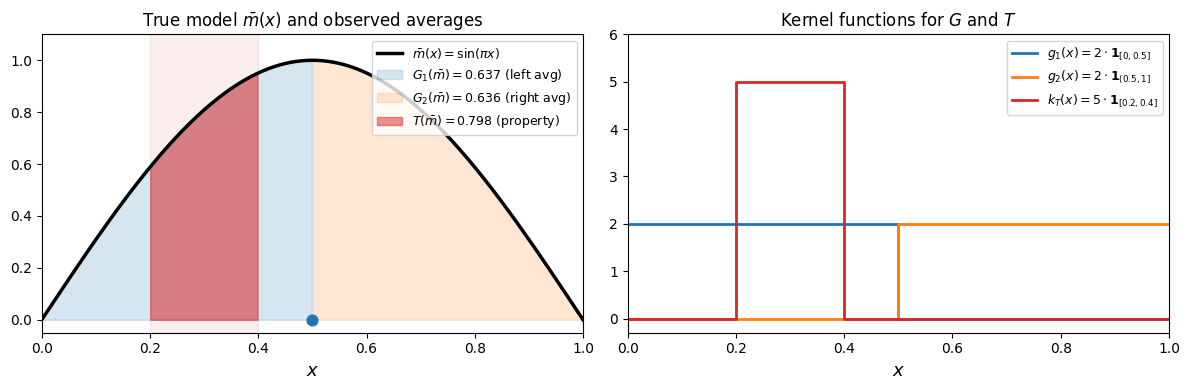

In [5]:
xs = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: true model + shaded regions ─────────────────────────────────────
ax = axes[0]
ax.plot(xs, np.sin(np.pi * xs), 'k-', lw=2.5, label=r'$\bar{m}(x) = \sin(\pi x)$')
ax.fill_between(xs, 0, np.sin(np.pi * xs),
                where=(xs <= 0.5), alpha=0.18, color='C0',
                label=fr'$G_1(\bar{{m}}) = {d_clean[0]:.3f}$ (left avg)')
ax.fill_between(xs, 0, np.sin(np.pi * xs),
                where=(xs > 0.5), alpha=0.18, color='C1',
                label=fr'$G_2(\bar{{m}}) = {d_clean[1]:.3f}$ (right avg)')
ax.fill_between(xs, 0, np.sin(np.pi * xs),
                where=(xs >= 0.2) & (xs <= 0.4), alpha=0.5, color='C3',
                label=fr'$T(\bar{{m}}) = {p_true[0]:.3f}$ (property)')
ax.axvspan(0.2, 0.4, alpha=0.08, color='C3')
ax.scatter([0.5], [0], color='C0', s=60, zorder=5)
ax.set_xlabel('$x$', fontsize=13)
ax.set_title(r'True model $\bar{m}(x)$ and observed averages', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.1)

# ── Right: kernel functions ────────────────────────────────────────────────
ax2 = axes[1]
ax2.step(xs, g1(xs),  where='mid', lw=2, color='C0', label=r'$g_1(x)=2\cdot\mathbf{1}_{[0,0.5]}$')
ax2.step(xs, g2(xs),  where='mid', lw=2, color='C1', label=r'$g_2(x)=2\cdot\mathbf{1}_{(0.5,1]}$')
ax2.step(xs, k_T(xs), where='mid', lw=2, color='C3', label=r'$k_T(x)=5\cdot\mathbf{1}_{[0.2,0.4]}$')
ax2.set_xlabel('$x$', fontsize=13)
ax2.set_title('Kernel functions for $G$ and $T$', fontsize=12)
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1); ax2.set_ylim(-0.3, 6)

plt.tight_layout()
plt.show()

## 4. Support functions for the prior and data-error sets

| Set | Definition | Support function |
|---|---|---|
| $\mathcal{B} \subset L^2[0,1]$ | $\{m : \|m\|_{L^2} \le r_M\}$ | $\sigma_{\mathcal{B}}(q) = r_M \|q\|_{L^2}$ |
| $\mathcal{V} \subset \mathbb{R}^2$ | $\{\eta : \|\eta\| \le r_V\}$ | $\sigma_{\mathcal{V}}(\lambda) = r_V \|\lambda\|$ |

These are **both** instantiated with `pygeoinf.BallSupportFunction`.  
The key point: **`BallSupportFunction` takes any `HilbertSpace`** — including `intervalinf.Lebesgue` —
and calls only `H.inner_product`, `H.norm`, and `H.multiply`, all of which are implemented correctly
by the Lebesgue space (via numerical $L^2$ integration).

In [6]:
r_M = 1.5   # prior ball radius in L²[0,1]
r_V = 0.15  # data-noise ball radius in ℝ²

# Support function of the prior ball B ⊂ L²[0,1]
# σ_B(q) = r_M ‖q‖_{L²}  — uses M.norm() internally (numerical integration)
sigma_B = BallSupportFunction(M, center=M.zero, radius=r_M)

# Support function of the data-error ball V ⊂ ℝ²
# σ_V(λ) = r_V ‖λ‖  — uses D.norm() internally (Euclidean norm)
sigma_V = BallSupportFunction(D, center=D.zero, radius=r_V)

# Quick sanity check: evaluate both at non-trivial points
q_test = Function(function_domain, evaluate_callable=lambda x: np.sin(np.pi * x))
lam_test = D.from_components(np.array([1.0, 0.0]))

print(f"σ_B(sin(πx)) = r_M · ‖sin(πx)‖_L²")
print(f"             = {r_M} × {M.norm(q_test):.4f}  =  {sigma_B(q_test):.4f}")
print(f"  (exact: {r_M} × 1/√2 = {r_M / np.sqrt(2):.4f})  ✓")
print()
print(f"σ_V([1, 0]) = r_V · ‖[1,0]‖ = {sigma_V(lam_test):.4f}  (expected {r_V})")

σ_B(sin(πx)) = r_M · ‖sin(πx)‖_L²
             = 1.5 × 0.7071  =  1.0607
  (exact: 1.5 × 1/√2 = 1.0607)  ✓

σ_V([1, 0]) = r_V · ‖[1,0]‖ = 0.1500  (expected 0.15)


## 5. The Master Dual Cost Function $\varphi(\lambda;\, q)$

For a fixed direction $q \in \mathcal{P} = \mathbb{R}^1$ the **master dual cost** is:

$$
\varphi(\lambda;\, q)
= \underbrace{\langle \lambda, \tilde{d} \rangle_{\mathcal{D}}}_{\text{data fit}}
+ \underbrace{\sigma_{\mathcal{B}}\!\left(T^* q - G^* \lambda\right)}_{\text{model-space residual norm in }L^2}
+ \underbrace{\sigma_{\mathcal{V}}(-\lambda)}_{\text{noise ball penalty}}
$$

and the support of the admissible property set is

$$h_{\mathcal{U}}(q) = \inf_{\lambda \in \mathbb{R}^2} \varphi(\lambda;\, q).$$

`DualMasterCostFunction` in `pygeoinf.backus_gilbert` implements $\varphi(\lambda; q)$ and its
subgradient. The intermediate term $G^*\lambda \in L^2[0,1]$ is the `SOLAOperator` adjoint —
a function reconstruction from data coefficients.

In [7]:
# Direction q = +e₁ ∈ P = ℝ¹  →  upper bound on T(m)
q_up = P.from_components(np.array([1.0]))

cost_fn = DualMasterCostFunction(
    data_space          = D,
    property_space      = P,
    model_space         = M,
    G                   = G,
    T                   = T,
    model_prior_support = sigma_B,
    data_error_support  = sigma_V,
    observed_data       = d_tilde,
    q_direction         = q_up,
)

# Sanity check: evaluate at λ=0  →  φ(0; q) = σ_B(T*q)
lam0 = D.zero
phi_at_zero = cost_fn(lam0)
Tstar_q_norm = M.norm(T.adjoint(q_up))

print(f"DualMasterCostFunction built ✓")
print(f"φ(0; +e₁) = σ_B(T*q)  =  {r_M} × ‖T*e₁‖_L²  =  {phi_at_zero:.4f}")
print(f"‖T*e₁‖_L² = ‖k_T‖_L² = {Tstar_q_norm:.4f}  (check: √(∫ 25·1_[0.2,0.4] dx) = 5√0.2 = {5*np.sqrt(0.2):.4f})")

DualMasterCostFunction built ✓
φ(0; +e₁) = σ_B(T*q)  =  1.5 × ‖T*e₁‖_L²  =  3.3558
‖T*e₁‖_L² = ‖k_T‖_L² = 2.2372  (check: √(∫ 25·1_[0.2,0.4] dx) = 5√0.2 = 2.2361)


### Visualizing $\varphi(\lambda;\, q)$ over $\mathbb{R}^2$

Since $\mathcal{D} = \mathbb{R}^2$, we can plot the full landscape of
$\varphi(\lambda_1, \lambda_2;\, q)$.

#### Non-differentiability structure

$\varphi$ is a sum of three terms; non-differentiability arises from the two norm terms:

1. **$r_V\|\lambda\|_D$ — kink at $\lambda = 0$.**
   The Euclidean norm $\|\lambda\|_D$ has a kink at the origin: its subdifferential there is the
   whole ball $r_V\bar{B}_D$ instead of a single vector. This contributes a **single non-differentiable
   point** at $\lambda = (0, 0)$.

2. **$r_M\|T^*q - G^*\lambda\|_M$ — kink on $\{G^*\lambda = T^*q\}$.**
   This term is non-differentiable wherever $G^*\lambda = T^*q$ in $L^2[0,1]$.
   Here $(G^*\lambda)(x) = 2\lambda_1\mathbf{1}_{[0,0.5]} + 2\lambda_2\mathbf{1}_{(0.5,1]}$,
   a piecewise constant function with one break at $x=\tfrac12$.
   Meanwhile $(T^*q)(x) = 5q\cdot\mathbf{1}_{[0.2,0.4]}$ has breaks at $0.2$ and $0.4$.
   Since $T^*q \notin \operatorname{span}\{g_1, g_2\}$ for any finite $\lambda$, this set is
   **empty** — term 2 is $C^1$ everywhere.

**Conclusion:** $\varphi$ is non-differentiable at **exactly one point in $\mathbb{R}^2$** — the origin
$\lambda = 0$. This is a **point kink**, not a ridge or edge. In the level curves it appears as a
slight "corner" near $\lambda = 0$, with the noise ball $\partial\mathcal{V}$ (radius $r_V = 0.15$) as the
geometric object that generates the kink.


Grid evaluated: min φ = 3.1158,  max φ = 6.9495


INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol V from STIXNonUnicode


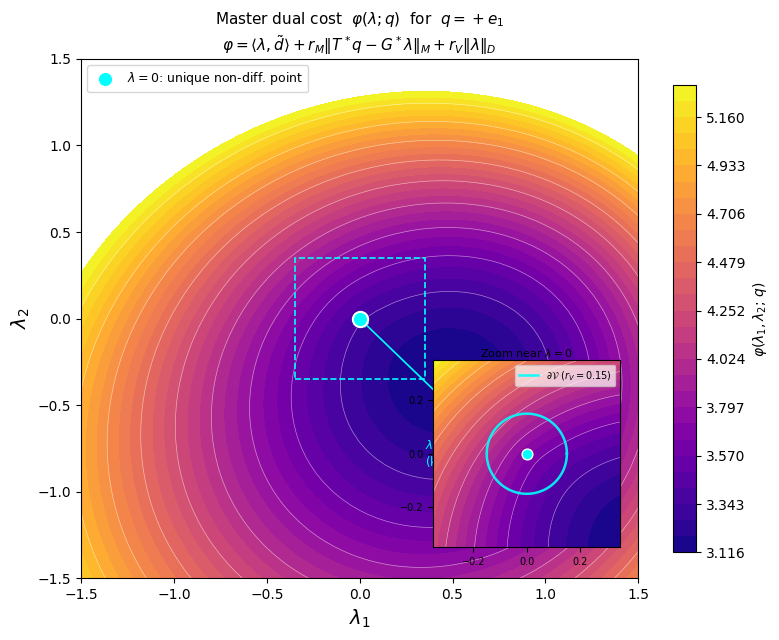

In [8]:
# Evaluate φ(λ₁, λ₂; q) on a 2D grid
n_grid = 65
lam1_vals = np.linspace(-1.5, 1.5, n_grid)
lam2_vals = np.linspace(-1.5, 1.5, n_grid)
L1, L2 = np.meshgrid(lam1_vals, lam2_vals)

PHI = np.full((n_grid, n_grid), np.nan)
for i in range(n_grid):
    for j in range(n_grid):
        lam_ij = D.from_components(np.array([L1[i, j], L2[i, j]]))
        PHI[i, j] = cost_fn(lam_ij)

print(f"Grid evaluated: min φ = {PHI.min():.4f},  max φ = {PHI.max():.4f}")

# ── Fine grid around origin for the inset ────────────────────────────────
zoom = 0.35        # half-width of inset region
n_zoom = 80
zv = np.linspace(-zoom, zoom, n_zoom)
ZL1, ZL2 = np.meshgrid(zv, zv)
ZPHI = np.full((n_zoom, n_zoom), np.nan)
for i in range(n_zoom):
    for j in range(n_zoom):
        lam_ij = D.from_components(np.array([ZL1[i, j], ZL2[i, j]]))
        ZPHI[i, j] = cost_fn(lam_ij)

# ── Main figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6.5))
levels = np.linspace(PHI.min(), np.percentile(PHI, 85), 30)
cf = ax.contourf(L1, L2, PHI, levels=levels, cmap='plasma')
ct = ax.contour(L1, L2, PHI, levels=levels[::3], colors='white', linewidths=0.5, alpha=0.5)
plt.colorbar(cf, ax=ax, label=r'$\varphi(\lambda_1, \lambda_2;\, q)$', shrink=0.9)

# Mark the unique non-differentiable point at the origin
ax.scatter([0], [0], s=120, color='cyan', edgecolors='white', lw=1.5,
           zorder=10, label=r'$\lambda=0$: unique non-diff. point')
ax.annotate(r'$\lambda=0$' + '\n' + r'(kink from $\sigma_{\mathcal{V}}(-\lambda)=r_V\|\lambda\|$)',
            xy=(0, 0), xytext=(0.35, -0.85),
            fontsize=8.5, color='cyan',
            arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2))

# Inset box outline
rect_kw = dict(linewidth=1.2, edgecolor='cyan', facecolor='none', linestyle='--')
import matplotlib.patches as mpatches
ax.add_patch(mpatches.Rectangle((-zoom, -zoom), 2*zoom, 2*zoom, **rect_kw, zorder=9))

ax.set_xlabel(r'$\lambda_1$', fontsize=14)
ax.set_ylabel(r'$\lambda_2$', fontsize=14)
ax.set_title(
    r'Master dual cost  $\varphi(\lambda; q)$  for  $q = +e_1$' + '\n'
    r'$\varphi = \langle\lambda,\tilde{d}\rangle + r_M\|T^*q - G^*\lambda\|_M + r_V\|\lambda\|_D$',
    fontsize=11
)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

# ── Inset: zoomed view of the kink at λ=0 ────────────────────────────────
axins = ax.inset_axes([0.62, 0.06, 0.36, 0.36])   # [left, bottom, width, height] in axes coords

z_levels = np.linspace(ZPHI.min(), ZPHI.max(), 28)
axins.contourf(ZL1, ZL2, ZPHI, levels=z_levels, cmap='plasma')
axins.contour(ZL1, ZL2, ZPHI, levels=z_levels[::3], colors='white', linewidths=0.4, alpha=0.6)

# Noise ball circle — the boundary of V is what causes the kink
theta = np.linspace(0, 2*np.pi, 200)
axins.plot(r_V * np.cos(theta), r_V * np.sin(theta),
           '-', color='cyan', lw=1.8, alpha=0.9, label=fr'$\partial\mathcal{{V}}$ ($r_V={r_V}$)')

# Mark origin
axins.scatter([0], [0], s=60, color='cyan', edgecolors='white', lw=1, zorder=10)

axins.set_xlim(-zoom, zoom)
axins.set_ylim(-zoom, zoom)
axins.set_aspect('equal')
axins.set_xticks([-0.2, 0, 0.2])
axins.set_yticks([-0.2, 0, 0.2])
axins.tick_params(labelsize=7)
axins.set_title('Zoom near $\\lambda=0$', fontsize=8, pad=2)
axins.legend(fontsize=7, loc='upper right', framealpha=0.7)

plt.tight_layout()
plt.show()


### Minimizing $\varphi(\lambda;\, q)$ with subgradient descent

`SubgradientDescent` from pygeoinf minimizes $\varphi$ using the subgradient oracle built into
`DualMasterCostFunction._subgradient`. The step size is constant; we track the best iterate.

In [9]:
optimizer = SubgradientDescent(
    cost_fn,
    step_size         = 0.025,
    max_iterations    = 600,
    store_iterates    = True,
    stagnation_window = 80,
)

result_up = optimizer.solve(D.from_components(np.array([1.0, 0.0])))   # q = +e₁  →  upper bound

lam_star = D.to_components(result_up.x_best)
h_upper  = result_up.f_best           # = h_U(+e₁)

print(f"Converged    : {result_up.converged}")
print(f"Iterations   : {result_up.num_iterations}")
print(f"λ*           : [{lam_star[0]:.4f}, {lam_star[1]:.4f}]")
print(f"φ(λ*; +e₁)   : {h_upper:.4f}   →  upper bound on T(m̄)")

Converged    : False
Iterations   : 600
λ*           : [0.4845, -0.3483]
φ(λ*; +e₁)   : 3.1153   →  upper bound on T(m̄)


INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode


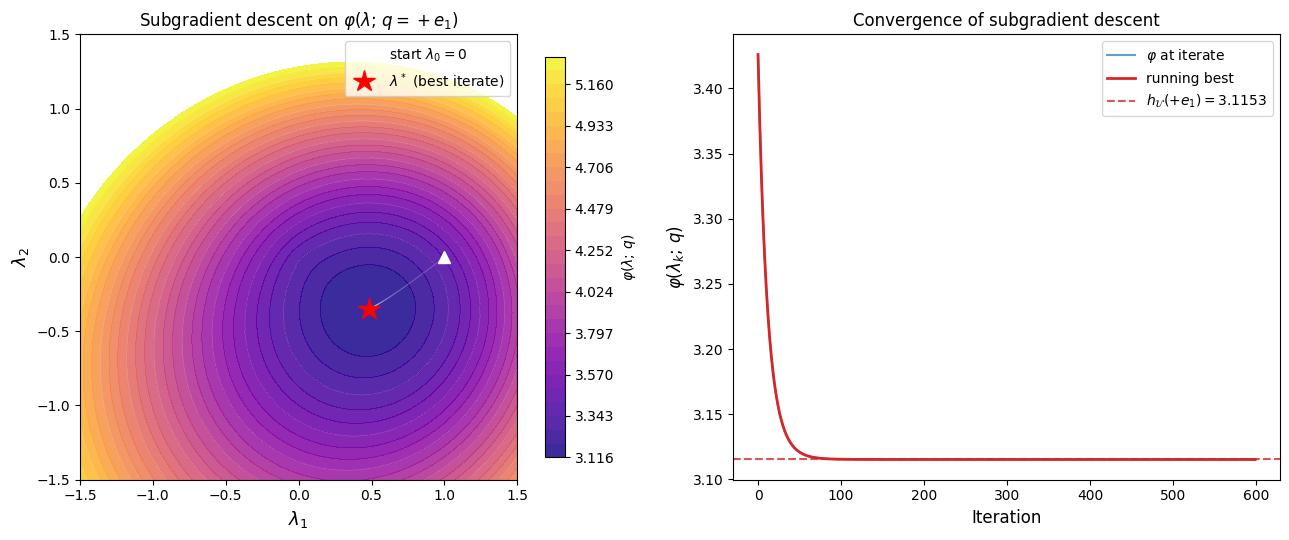

In [13]:
path = np.array([D.to_components(x) for x in result_up.iterates])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: φ landscape + descent path ──────────────────────────────────────
ax = axes[0]
cf = ax.contourf(L1, L2, PHI, levels=levels, cmap='plasma', alpha=0.85)
ax.contour(L1, L2, PHI, levels=levels[::3], colors='white', linewidths=0.4, alpha=0.4)
plt.colorbar(cf, ax=ax, label=r'$\varphi(\lambda;\, q)$', shrink=0.9)

# Descent trajectory (thin + fading alpha)
n_path = len(path)
for k in range(n_path - 1):
    alpha_k = 0.15 + 0.65 * k / max(n_path - 1, 1)
    ax.plot(path[k:k+2, 0], path[k:k+2, 1], '-', color='white',
            lw=0.8, alpha=alpha_k)
ax.plot(path[0, 0], path[0, 1], 'w^', ms=9, label='start $\\lambda_0 = 0$')
ax.plot(lam_star[0], lam_star[1], 'r*', ms=16, label=r'$\lambda^*$ (best iterate)', zorder=5)
ax.set_xlabel(r'$\lambda_1$', fontsize=13)
ax.set_ylabel(r'$\lambda_2$', fontsize=13)
ax.set_title(r'Subgradient descent on $\varphi(\lambda;\, q=+e_1)$', fontsize=12)
ax.legend(fontsize=10)

# ── Right: convergence history ─────────────────────────────────────────────
ax2 = axes[1]
fvals = result_up.function_values
ax2.plot(fvals, color='C0', lw=1.5, alpha=0.7, label='$\\varphi$ at iterate')
ax2.plot(np.minimum.accumulate(fvals), color='C3', lw=2, label='running best')
ax2.axhline(h_upper, color='C3', ls='--', lw=1.5, alpha=0.8,
            label=fr'$h_{{\mathcal{{U}}}}(+e_1) = {h_upper:.4f}$')
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel(r'$\varphi(\lambda_k;\, q)$', fontsize=12)
ax2.set_title('Convergence of subgradient descent', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 6. Property bounds: the admissible interval $\mathcal{U} \subset \mathbb{R}$

Since $\mathcal{P} = \mathbb{R}^1$ the admissible set $\mathcal{U}$ is just an interval $[p_-, p_+]$ with:

$$p_+ = h_{\mathcal{U}}(+e_1) = \inf_\lambda \varphi(\lambda;\, +e_1), \qquad
p_- = -h_{\mathcal{U}}(-e_1) = - \inf_\lambda \varphi(\lambda;\, -e_1)$$

We compute both by running the optimiser for $q = \pm e_1$.

In [11]:
# Upper bound already computed: h_upper = h_U(+e₁)

# Lower bound: set q = -e₁, then p_- = -h_U(-e₁)
q_down = P.from_components(np.array([-1.0]))
cost_fn.set_direction(q_down)

result_dn = SubgradientDescent(
    cost_fn,
    step_size         = 0.025,
    max_iterations    = 600,
    stagnation_window = 80,
).solve(D.zero)

h_lower = -result_dn.f_best   # p_- = -h_U(-e₁)

p_true_val = float(p_true[0])
inside = h_lower <= p_true_val <= h_upper

print(f"Admissible interval U = [{h_lower:.4f},  {h_upper:.4f}]")
print(f"True property T(m̄)   =  {p_true_val:.4f}")
print(f"T(m̄) ∈ U ?            {'YES ✓' if inside else 'NO ✗'}  (must be YES)")

Admissible interval U = [-1.8784,  3.1153]
True property T(m̄)   =  0.7976
T(m̄) ∈ U ?            YES ✓  (must be YES)


INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol P from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol R from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol U from STIXNonUnicode
INFO

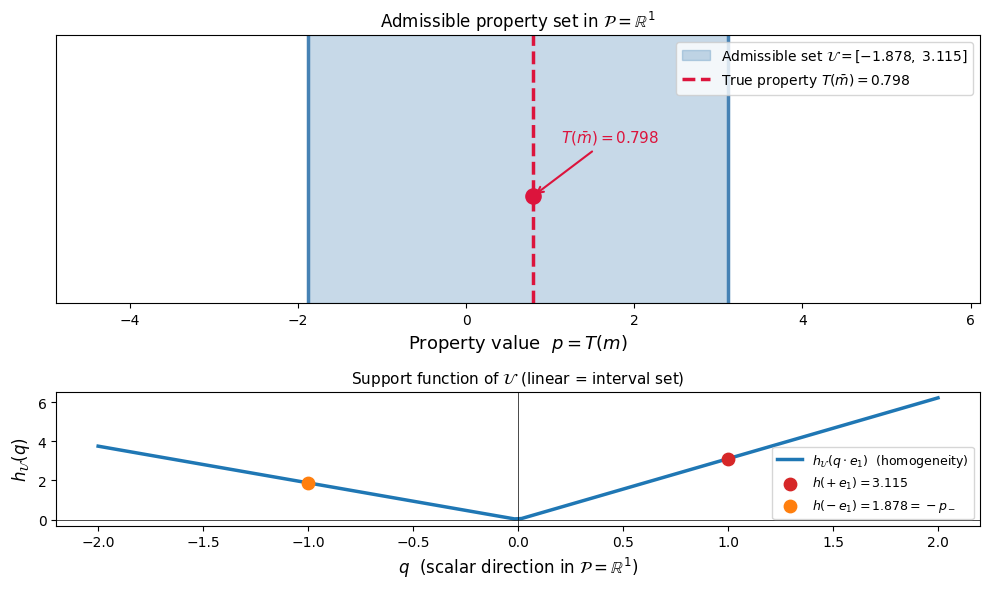


Interval width = 4.9937  (noise 0.15, prior radius 1.5)


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6),
                         gridspec_kw={'height_ratios': [2, 1]})

# ── Top: admissible interval with true property ───────────────────────────
ax = axes[0]
margin = (h_upper - h_lower) * 0.6
xlim = (h_lower - margin, h_upper + margin)
ax.axvspan(h_lower, h_upper, alpha=0.30, color='steelblue',
           label=fr'Admissible set $\mathcal{{U}} = [{h_lower:.3f},\; {h_upper:.3f}]$')
ax.axvline(h_lower, color='steelblue', lw=2.5)
ax.axvline(h_upper, color='steelblue', lw=2.5)
ax.axvline(p_true_val, color='crimson', lw=2.5, ls='--',
           label=fr'True property $T(\bar{{m}}) = {p_true_val:.3f}$')
ax.scatter([p_true_val], [0], color='crimson', s=120, zorder=5)
ax.annotate(fr'$T(\bar{{m}}) = {p_true_val:.3f}$',
            xy=(p_true_val, 0), xytext=(p_true_val + 0.03*(xlim[1]-xlim[0]), 0.2),
            fontsize=11, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))
ax.set_xlim(xlim)
ax.set_ylim(-0.4, 0.6)
ax.set_yticks([])
ax.set_xlabel('Property value  $p = T(m)$', fontsize=13)
ax.set_title('Admissible property set in $\mathcal{P} = \mathbb{R}^1$', fontsize=12)
ax.legend(fontsize=10)

# ── Bottom: support function h_U(q) for q ∈ [-2, 2] (1D linear check) ──────
ax2 = axes[1]
q_scan = np.linspace(-2.0, 2.0, 120)
# h_U(q·e₁) = q · h_U(e₁) if q>0, else -q · h_U(-e₁) (by homogeneity)
h_scan = np.where(q_scan >= 0, q_scan * h_upper, -q_scan * (-h_lower))
ax2.plot(q_scan, h_scan, 'C0-', lw=2.5, label=r'$h_{\mathcal{U}}(q \cdot e_1)$  (homogeneity)')
ax2.axhline(0, color='k', lw=0.5)
ax2.axvline(0, color='k', lw=0.5)
ax2.scatter([1, -1], [h_upper, h_upper*(h_lower/h_lower)], s=0)  # force y range
ax2.scatter([1], [h_upper], color='C3', s=80, zorder=5,
            label=fr'$h(\!+e_1) = {h_upper:.3f}$')
ax2.scatter([-1], [-h_lower], color='C1', s=80, zorder=5,
            label=fr'$h(\!-e_1) = {(-h_lower):.3f} = -p_-$')
ax2.set_xlabel(r'$q$  (scalar direction in $\mathcal{P} = \mathbb{R}^1$)', fontsize=12)
ax2.set_ylabel(r'$h_{\mathcal{U}}(q)$', fontsize=12)
ax2.set_title('Support function of $\mathcal{U}$ (linear = interval set)', fontsize=11)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nInterval width = {h_upper - h_lower:.4f}  "
      f"(noise {r_V:.2f}, prior radius {r_M:.1f})")

## Summary

This notebook demonstrates the full **master dual equation** workflow using:

| Component | Source | Role |
|---|---|---|
| `Lebesgue(0, [0,1])` | `intervalinf` | Model space $L^2[0,1]$ |
| `SOLAOperator` | `intervalinf` | $G: L^2 \to \mathbb{R}^2$ and $T: L^2 \to \mathbb{R}^1$ with automatic adjoint |
| `BallSupportFunction(M, ...)` | `pygeoinf` | $\sigma_\mathcal{B}$ using $L^2$ norm via `M.norm()` |
| `BallSupportFunction(D, ...)` | `pygeoinf` | $\sigma_\mathcal{V}$ using Euclidean norm |
| `DualMasterCostFunction` | `pygeoinf.backus_gilbert` | $\varphi(\lambda; q)$ with subgradient oracle |
| `SubgradientDescent` | `pygeoinf` | Minimizes $\varphi$ over $\lambda \in \mathbb{R}^2$ |

**Key point:** `pygeoinf.BallSupportFunction` and `DualMasterCostFunction` are fully abstract — they
call only `H.inner_product`, `H.norm`, `H.add`, `H.multiply`, and `H.subtract`. Since
`intervalinf.Lebesgue` implements all of these (via numerical $L^2$ integration), the convex
analysis machinery works on infinite-dimensional function spaces *out of the box*, with no
extra glue code required.